# 📦 Amazon Sales Performance & Exploratory Data Analysis

## 📌 Executive Summary
This notebook analyzes e-commerce sales transactions from an Amazon seller dataset (~129k records). 
The analysis covers full-stack workflows: connecting Python to Dockerized PostgreSQL, evaluating operational efficiency, identifying core revenue drivers via Pareto distribution, assessing fulfillment channel performance, and measuring financial loss due to order cancellations.

In [1]:
import os 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv


# Setting a styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Connecting a database
load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Connecting to PostgreSQL is success!")

Connecting to PostgreSQL is success!


### 1. Revenue Distribution by Product Category (ABC Analysis)

**Key Insights:**
* **Revenue Concentration:** Sales follow the Pareto principle — the top two categories (**Set** at ~$35.5M INR and **Kurta** at ~$19.3M INR) generate over 75% of total net revenue.
* **Low-Performing Categories:** Categories such as *Dupatta*, *Saree*, and *Bottom* contribute negligibly to overall revenue (< 1% combined).
* **Actionable Recommendation:** Optimize inventory depth and logistics operations for *Set* and *Kurta* while evaluating storage allocations for long-tail inventory.

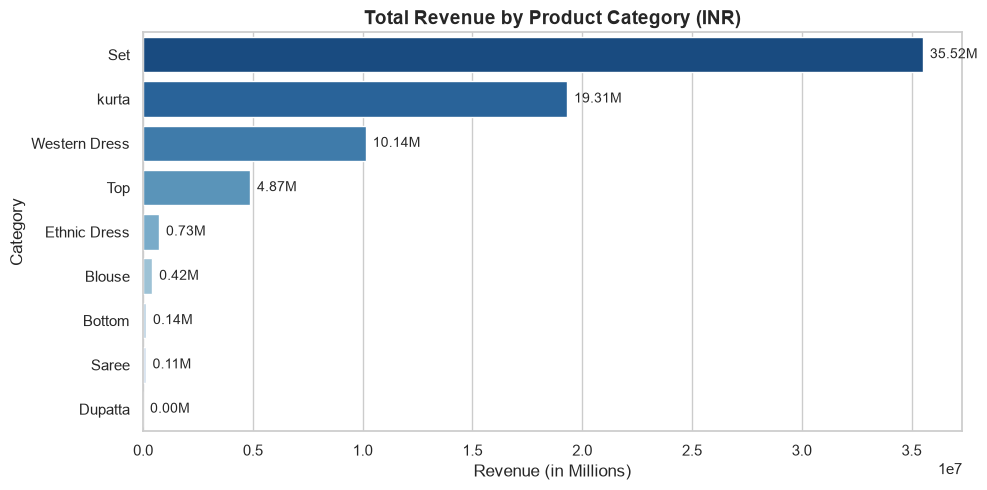

In [2]:
query_categories = """
SELECT 
    category,
    ROUND(SUM(amount)::numeric, 2) AS revenue
FROM amazon_sales
WHERE status NOT IN ('Cancelled', 'Pending') AND amount IS NOT NULL
GROUP BY category
ORDER BY revenue DESC;
"""
df_cat = pd.read_sql(query_categories, engine)

plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=df_cat, 
    x='revenue', 
    y='category', 
    hue='category', 
    palette='Blues_r', 
    legend=False
)

plt.title('Total Revenue by Product Category (INR)', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (in Millions)', fontsize=12)
plt.ylabel('Category', fontsize=12)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width/1e6:.2f}M',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points')
plt.tight_layout()
plt.show()

### 2. Weekly Revenue Dynamics & Trend Analysis

**Key Insights:**
* **Peak Sales Window:** Sales peaked significantly in April 2022, followed by a steady contraction throughout May and June.
* **Data Normalization:** Weekly aggregation (`DATE_TRUNC('week')`) was implemented starting from late March (`2022-03-25`) to remove early data collection anomalies.
* **Business Impact:** The post-April slowdown highlights potential seasonal demand shifts, requiring targeted promotional strategies during off-peak months.

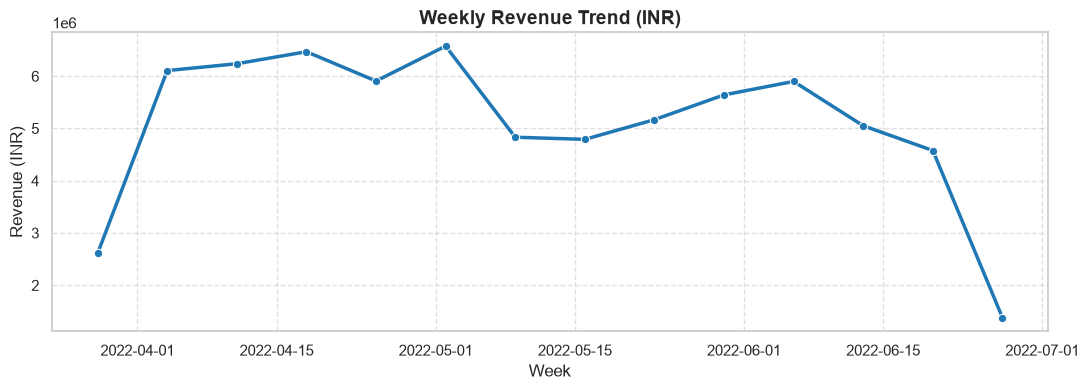

In [5]:
#Spliting to  the week revenue to make graph more correct
query_weekly = """
SELECT 
    DATE_TRUNC('week', date)::date AS sales_week,
    ROUND(SUM(amount)::numeric, 2) AS weekly_revenue
FROM amazon_sales
WHERE status NOT IN ('Cancelled', 'Pending') 
  AND date >= '2022-03-25'
GROUP BY sales_week
ORDER BY sales_week;
"""

df_weekly = pd.read_sql(query_weekly, engine)

plt.figure(figsize=(11, 4))
sns.lineplot(data=df_weekly, x='sales_week', y='weekly_revenue', marker='o', linewidth=2.5, color='#1f77b4')

plt.title('Weekly Revenue Trend (INR)', fontsize=14, fontweight='bold')
plt.xlabel('Week', fontsize=12)
plt.ylabel('Revenue (INR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 3. Fulfillment Channel Efficiency (FBA vs. FBM)

**Key Insights:**
* **FBA Dominance:** **70.7%** of completed orders are processed through **Fulfilled by Amazon (FBA)**, while **29.3%** are fulfilled directly by the **Merchant (FBM)**.
* **Operational Strategy:** Leveraging Amazon's logistics ecosystem provides superior delivery reliability, driving higher conversion rates and Prime customer retention.

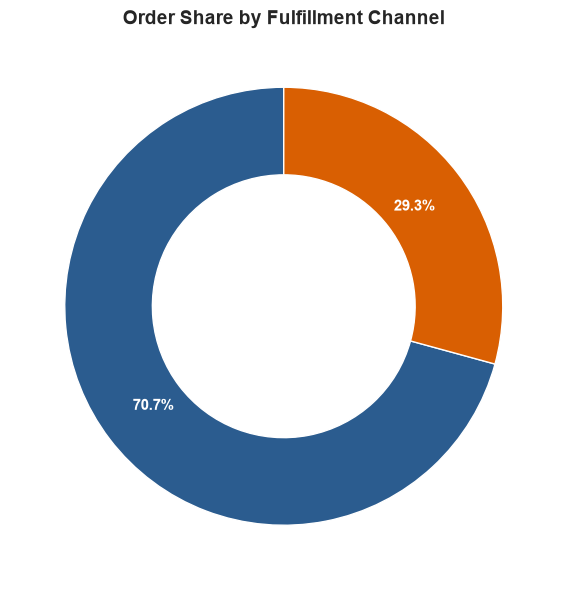

In [3]:
query_fulfilement = """
SELECT 
    fulfilment,
    COUNT(order_id) AS total_orders
FROM amazon_sales
WHERE status NOT IN ('Cancelled', 'Pending')
GROUP BY fulfilment;
"""

df_ful = pd.read_sql(query_fulfilement, engine)

plt.figure(figsize=(6, 6))
colors = ['#2b5c8f', '#d95f02']

plt.pie(
    df_ful['total_orders'], 
    labels=df_ful['fulfilment'], 
    autopct='%1.1f%%', 
    pctdistance=0.75,
    textprops={'color': 'white', 'weight': 'bold', 'fontsize': 11},
    startangle=90, 
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w')
)

plt.title('Order Share by Fulfillment Channel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Order Status Distribution & Revenue Leakage

**Key Insights:**
* **High Cancellation Volume:** Over **18,300 orders** (~14% of overall order volume) were canceled, representing a critical operational issue and lost potential gross revenue.
* **Returns & Bounce Rates:** Returns (*Shipped - Returned*) account for ~1,950 orders.
* **Actionable Recommendation:** Investigate cancellation touchpoints (such as payment gateway drop-offs, stockouts, or long delivery time estimates) to minimize revenue leakage.

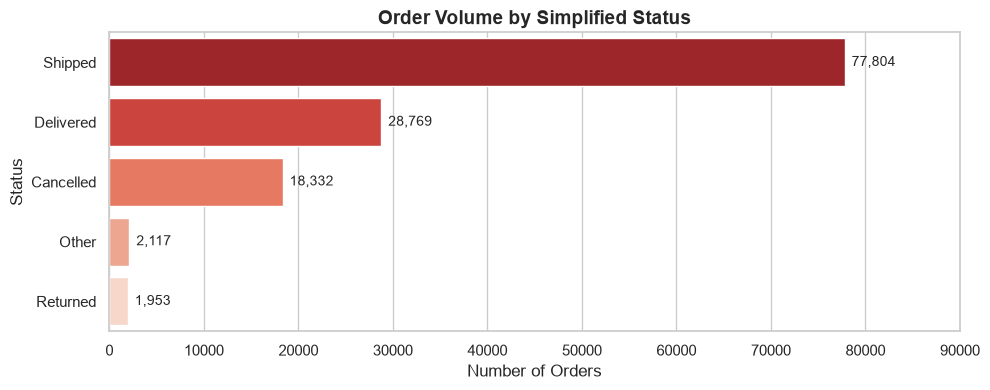

In [3]:
from sqlalchemy import text

query_status = text("""
    SELECT 
        CASE 
            WHEN status = 'Shipped' THEN 'Shipped'
            WHEN status LIKE 'Shipped - Delivered%' THEN 'Delivered'
            WHEN status = 'Cancelled' THEN 'Cancelled'
            WHEN status LIKE 'Shipped - Returned%' THEN 'Returned'
            ELSE 'Other'
        END AS simplified_status,
        COUNT(order_id) AS total_orders
    FROM amazon_sales
    GROUP BY simplified_status
    ORDER BY total_orders DESC;
""")

df_status = pd.read_sql(query_status, con=engine.connect())

plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=df_status, 
    x='total_orders', 
    y='simplified_status', 
    hue='simplified_status', 
    palette='Reds_r', 
    legend=False
)

plt.title('Order Volume by Simplified Status', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders', fontsize=12)
plt.ylabel('Status', fontsize=12)

plt.xlim(0, 90000)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width):,}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()